In [1]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import fiona
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from src.utils import split_pa_train_test_spatially, split_pa_train_test_kmeans
from src.pa_split import partition_sweep

In [3]:
region = 'swi'  # example region code
group = ''
group_ = '_' if group != '' else ''
gdf_map = gpd.read_file(f'data/raw/NCEAS/Borders/{region}.gpkg')  # path for a .gpkg

# read data\raw\NCEAS\Records\train_po\AWTtrain_po.csv with region variable
df_po = gpd.read_file(f'data/processed/NCEAS/Records/train_po/{region.upper()}train_po{group_}{group}.csv')


# data\raw\NCEAS\Records\test_pa\AWTtest_pa_bird.csv
df_pa = gpd.read_file(f'data/raw/NCEAS/Records/test_pa/{region.upper()}test_pa{group_}{group}.csv')
df_env = pd.read_csv(f'data/raw/NCEAS/Records/test_env/{region.upper()}test_env{group_}{group}.csv')
df_pa[['x','y']] = df_pa[['x','y']].astype('float')
# df_pa_tr, df_pa_te, foo1, foo2 = split_pa_train_test_spatially(df_pa, df_pa)

gdf_points_po = gpd.GeoDataFrame(
    df_po,
    geometry=gpd.points_from_xy(df_po.x, df_po.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa = gpd.GeoDataFrame(
    df_pa,
    geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )


# fig, ax1, ax2 = plt.subplots(figsize=(5, 5), nrows=1, ncols=2)
# fig, (ax1, ax2) = plt.subplots(figsize=(10, 5), nrows=1, ncols=2)
# gdf_map.plot(ax=ax1, color="whitesmoke", edgecolor="gray", linewidth=0.5)
# gdf_points_pa.plot(ax=ax1, color="green", markersize=2, label="Presence-Absence", alpha=0.9)
# gdf_map.plot(ax=ax2, color="whitesmoke", edgecolor="gray", linewidth=0.5)
# gdf_points_po.plot(ax=ax2, color="red", markersize=2, label="Presence-Only", alpha=0.9)


In [4]:
# read results output/integration_analysis/summary.csv
df_results = pd.read_csv(f'output/integration_analysis/summary_spatial_small_clusters.csv')



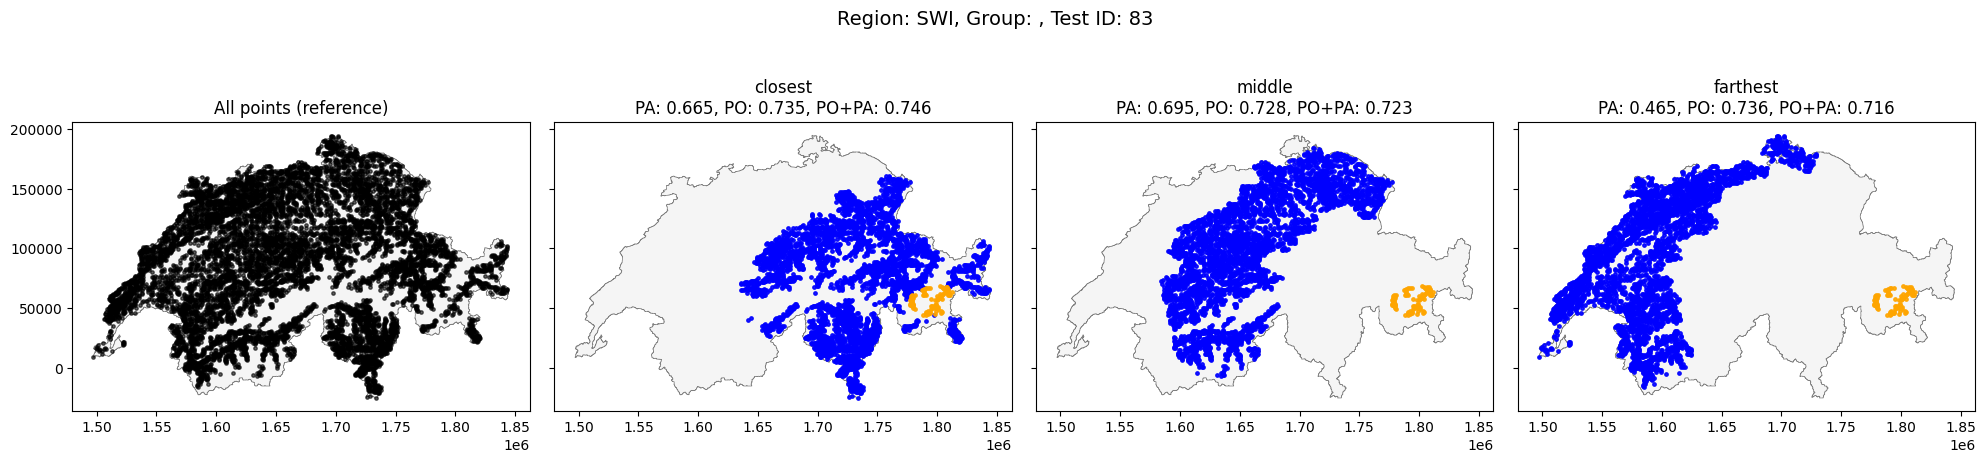

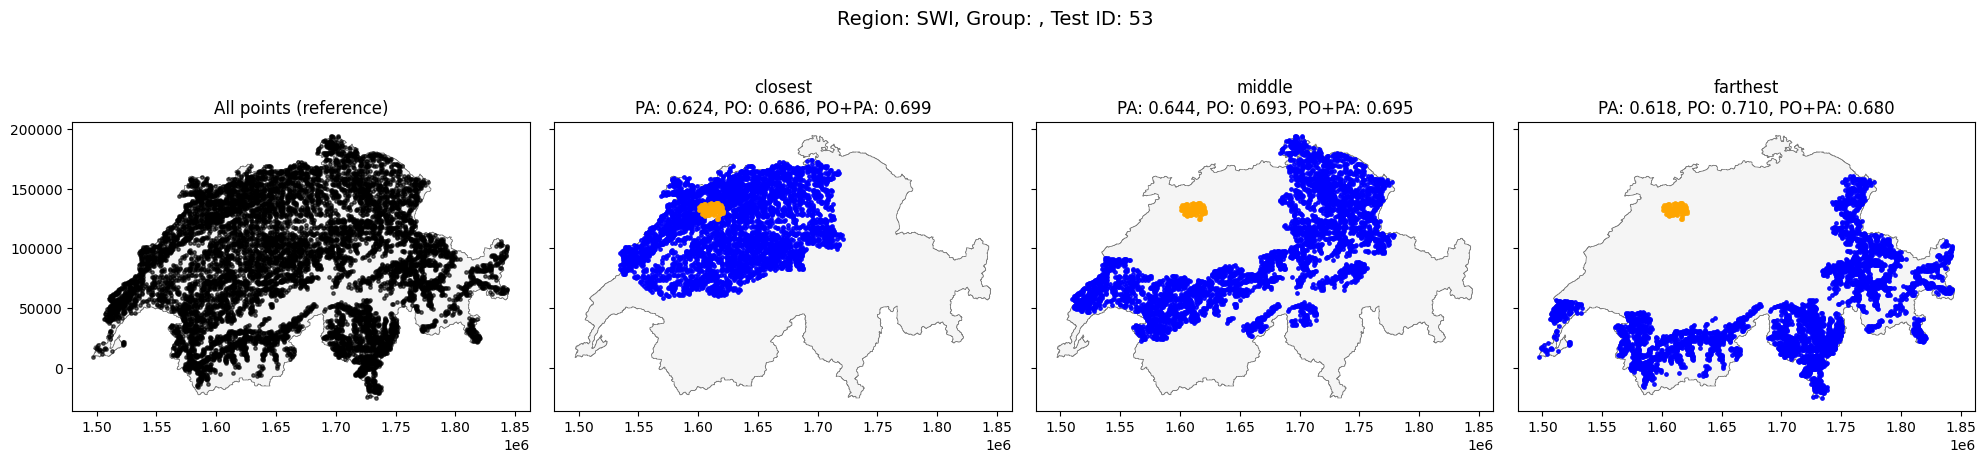

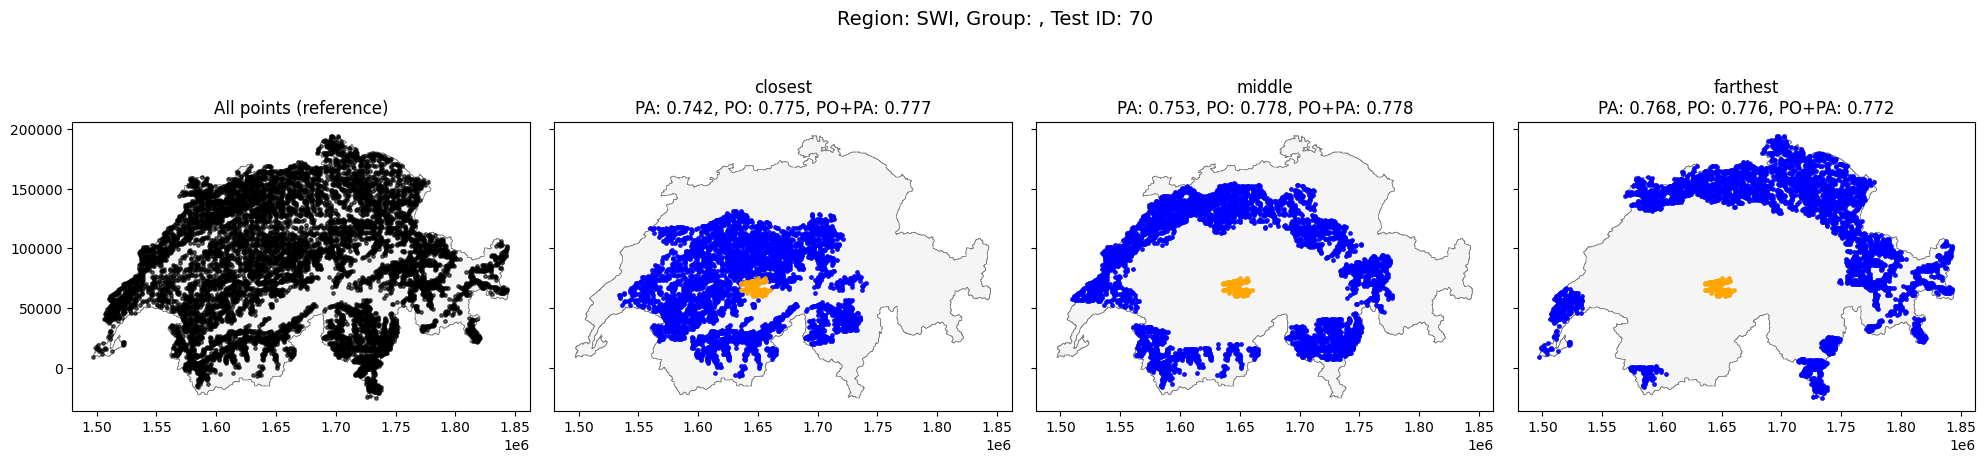

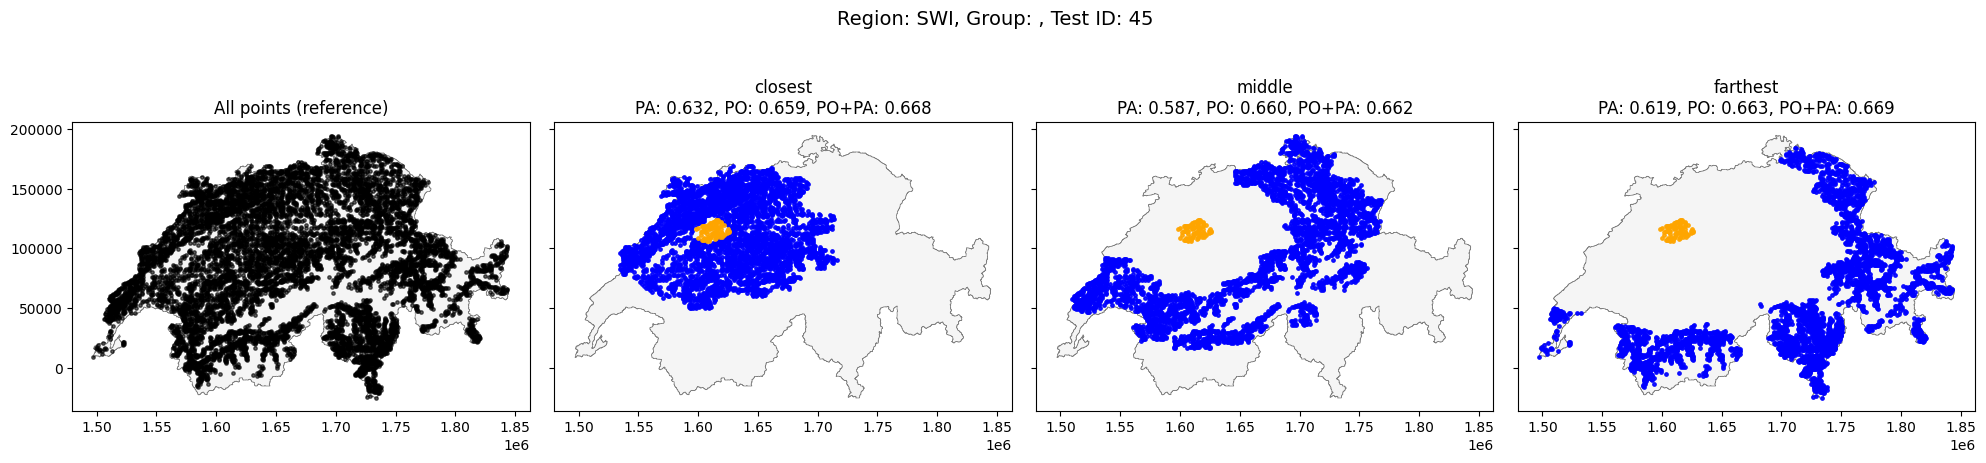

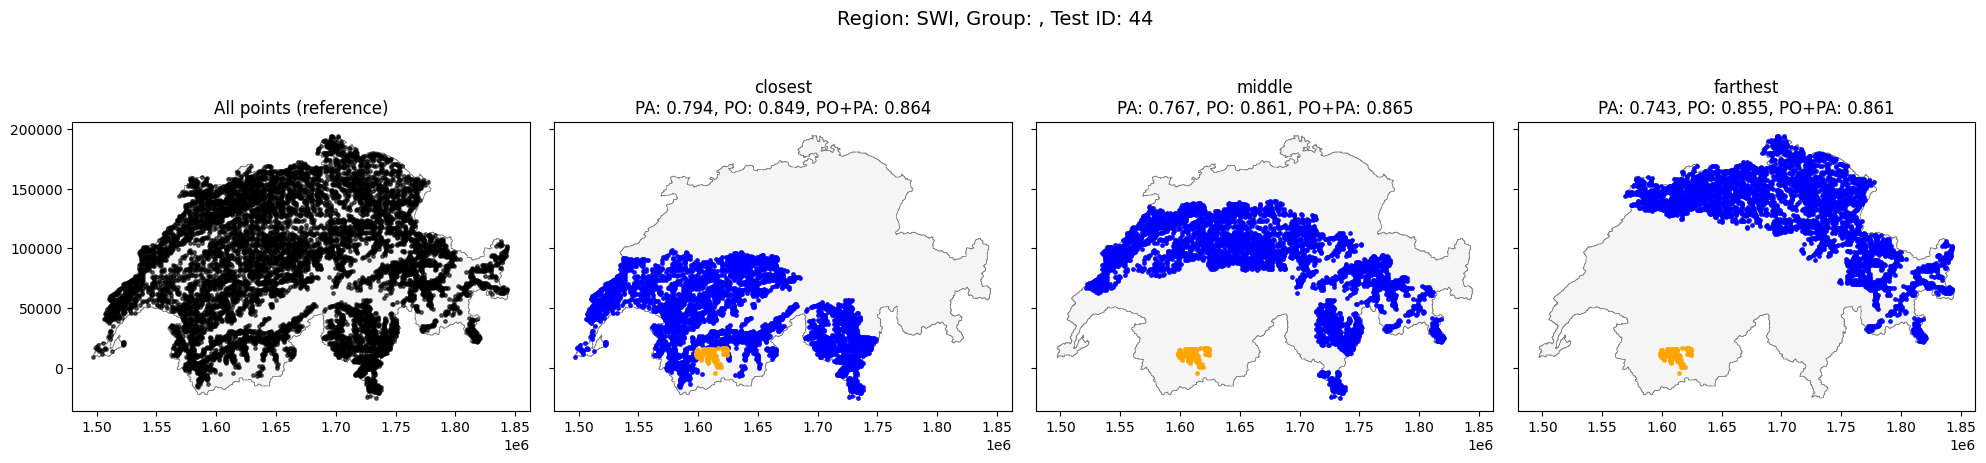

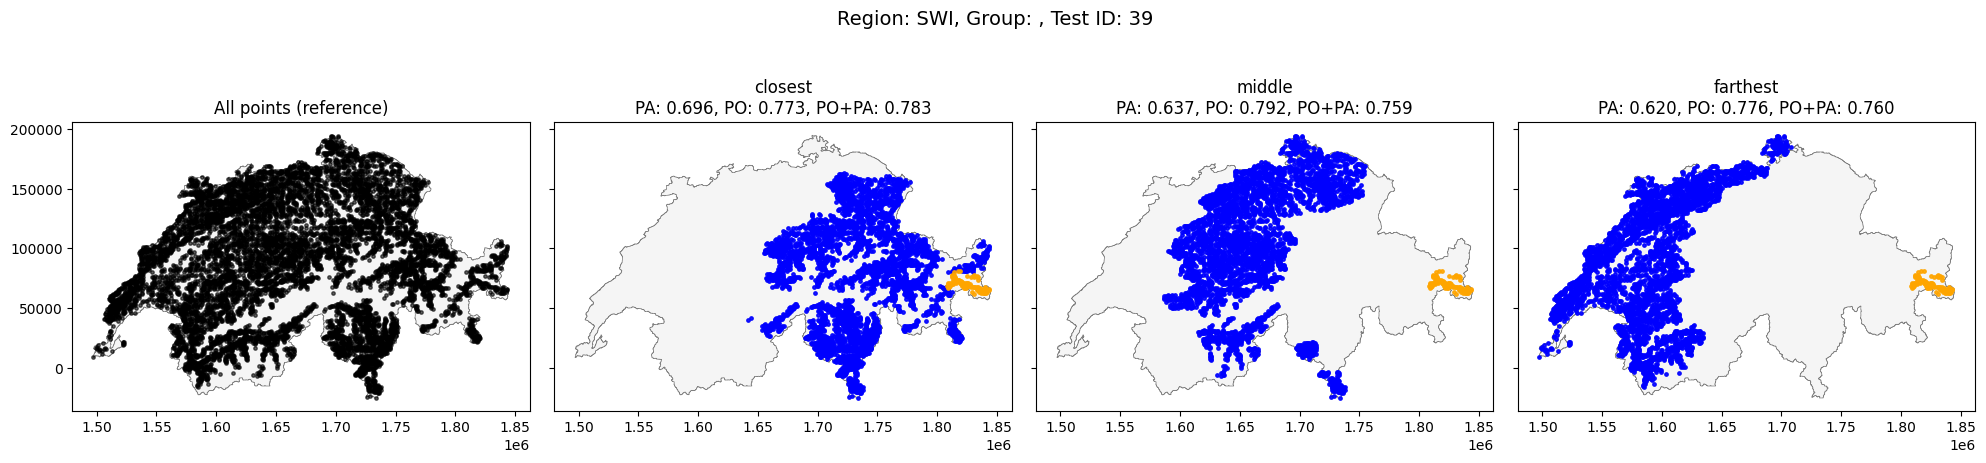

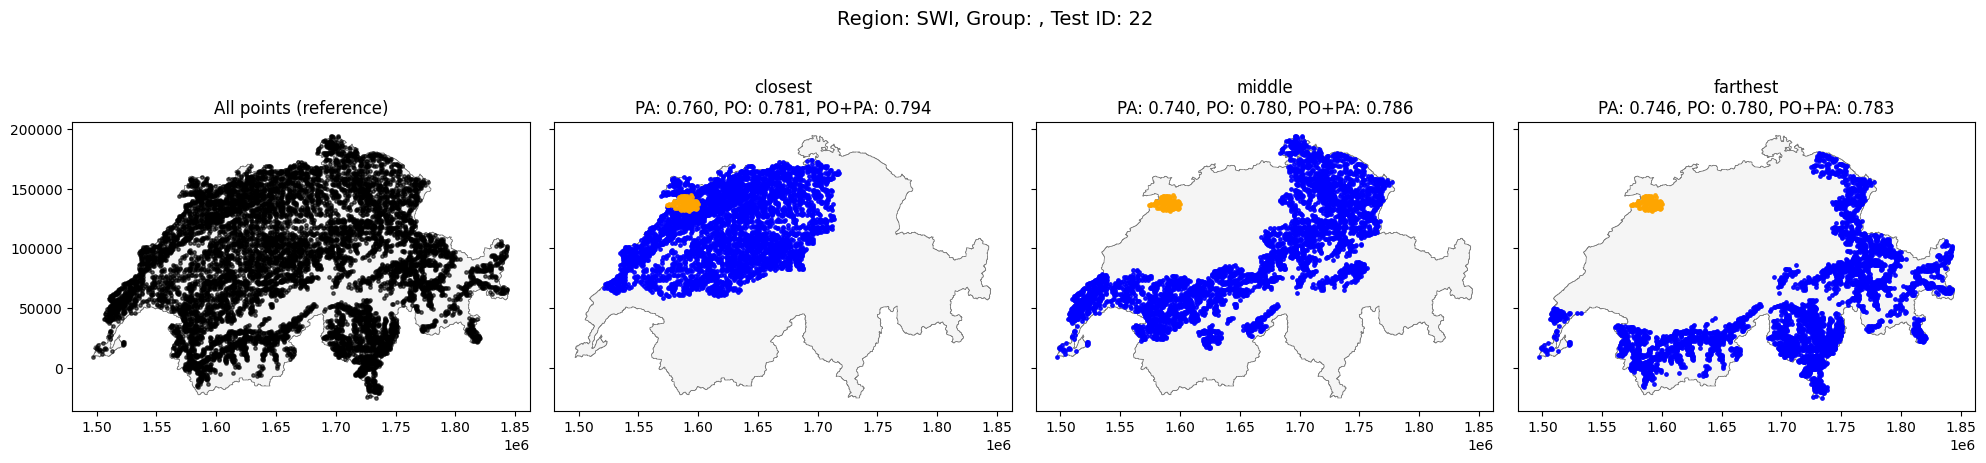

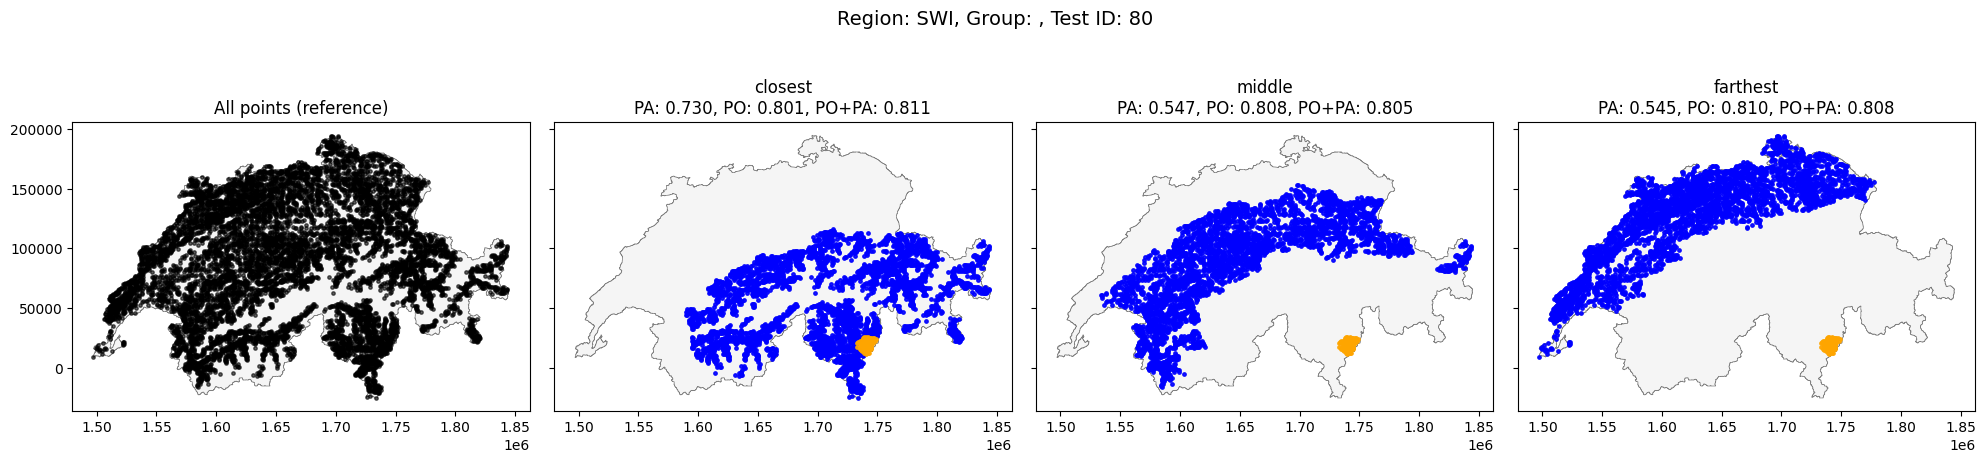

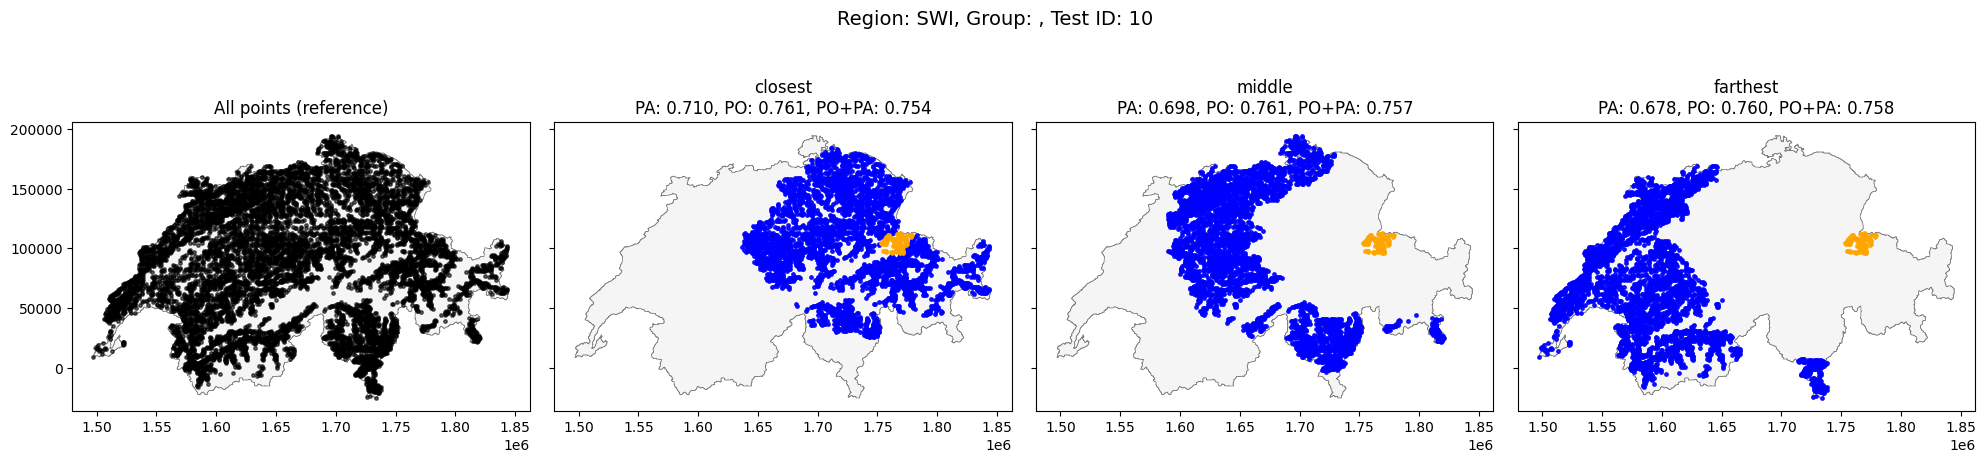

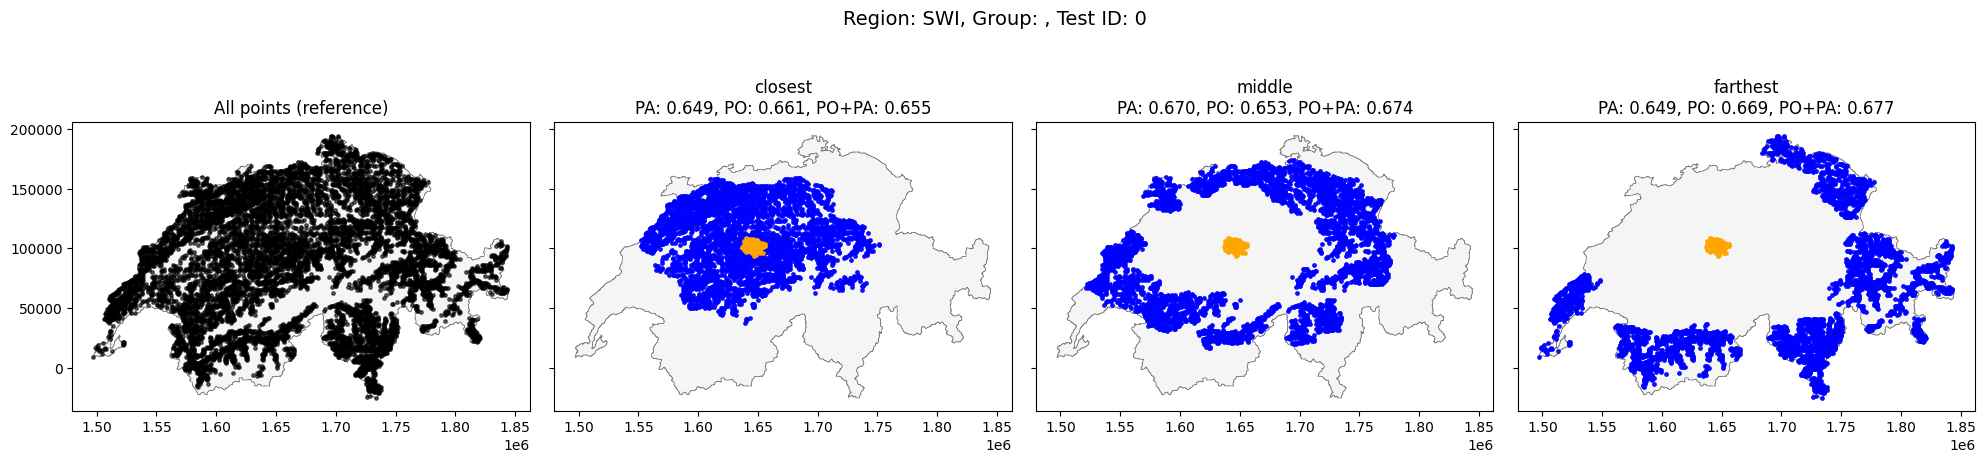

In [5]:
import ast
import matplotlib.pyplot as plt
import geopandas as gpd

unique_test_ids = df_results['test_id'].unique()
split_types = ['closest', 'middle', 'farthest']

for test_id in unique_test_ids:
    ncols = len(split_types) + 1  # +1 for reference plot
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), sharex=True, sharey=True)

    # ---------- Reference plot (all points) ----------
    ax_ref = axes[0]

    gdf_map.plot(ax=ax_ref, color="whitesmoke", edgecolor="gray", linewidth=0.5)

    gdf_all = gpd.GeoDataFrame(
        df_pa,
        geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
        crs=str(gdf_map.crs),
    )
    gdf_all.plot(ax=ax_ref, color="black", markersize=6, alpha=0.6)

    ax_ref.set_title("All points (reference)")

    # ---------- Split-specific plots ----------
    for i, split_type in enumerate(split_types, start=1):
        ax = axes[i]

        subset = df_results[
            (df_results['test_id'] == test_id)
            & (df_results['split_type'] == split_type)
        ]

        if subset.empty:
            ax.set_title(f"{split_type} (no data)")
            continue

        # safer than eval
        train_indexes = ast.literal_eval(subset['train_indexes'].values[0])
        test_indexes = ast.literal_eval(subset['test_indexes'].values[0])

        df_pa_tr = df_pa.iloc[train_indexes]
        df_pa_te = df_pa.iloc[test_indexes]

        gdf_pa_tr = gpd.GeoDataFrame(
            df_pa_tr,
            geometry=gpd.points_from_xy(df_pa_tr.x, df_pa_tr.y),
            crs=str(gdf_map.crs),
        )
        gdf_pa_te = gpd.GeoDataFrame(
            df_pa_te,
            geometry=gpd.points_from_xy(df_pa_te.x, df_pa_te.y),
            crs=str(gdf_map.crs),
        )

        gdf_map.plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)
        gdf_pa_tr.plot(ax=ax, color="blue", markersize=6, alpha=0.9)
        gdf_pa_te.plot(ax=ax, color="orange", markersize=6, alpha=0.9)

        auc_pa = subset['AUC_PA_only'].values[0]
        auc_po = subset['AUC_PO_only'].values[0]
        auc_popa = subset['AUC_PO_plus_PA'].values[0]
    
        # add all info in the title of auc and split type
        ax.set_title(
            f"{split_type}\nPA: {auc_pa:.3f}, PO: {auc_po:.3f}, PO+PA: {auc_popa:.3f}"
        )

    fig.suptitle(
        f"Region: {region.upper()}, Group: {group}, Test ID: {test_id}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

